# Visualise results

Given a single organoid UID, this notebook:
1. Loads the original mesh and computes HKS features
2. Runs the trained NN to get the reconstruction
3. Visualises original vs reconstructed HKS on the mesh surface
4. Shows per-scale error maps

In [5]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from meshplot import plot, subplot

sys.path.insert(0, '..')
sys.path.insert(0, '../..')

from dataset import OrganoidDataset
from dataset_cross import CrossPredictionDataset
from model import DiffusionNetAutoencoder 
from model_cross import DiffusionNetPredictor

## Configuration

Set the UID of the organoid to visualise and paths to data/model.

In [ ]:
# ---- User configuration ----
UID = 'day4p5_B03_144'  # <-- change this to the organoid you want to inspect

DATA_PATH = '../../Data/small_meshes'
MODEL_PATH = '../outputs/fate2hks/model_final.pt'
OP_CACHE_DIR = '../op_cache'

# Model hyperparameters (must match what was used during training)
K_EIG = 128
C_WIDTH = 32       


## Load dataset and find the requested UID

In [ ]:
dataset = CrossPredictionDataset(
    data_path=DATA_PATH,
    k_eig=K_EIG,
    op_cache_dir=OP_CACHE_DIR,
)

# Find the index for the requested UID
uid_to_idx = {e['id']: i for i, e in enumerate(dataset.entries)}

if UID not in uid_to_idx:
    available = sorted(uid_to_idx.keys())[:20]
    raise KeyError(
        f"UID '{UID}' not found in dataset. "
        f"Available UIDs (first 20): {available}"
    )

idx = uid_to_idx[UID]
print(f"Found UID '{UID}' at index {idx}")

## Load the sample and run the autoencoder

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load sample
sample = dataset[idx]
verts = sample['verts']
faces = sample['faces']
hks = sample['hks'].to(device)
fates = sample['fate_fields'].to(device)
mass = sample['mass'].to(device)
L = sample['L'].to(device)
evals = sample['evals'].to(device)
evecs = sample['evecs'].to(device)
gradX = sample['gradX'].to(device)
gradY = sample['gradY'].to(device)

n_hks = dataset.n_hks
n_fates = dataset.n_fates
print(f"Mesh: {verts.shape[0]} vertices, {faces.shape[0]} faces")
print(f"HKS channels: {n_hks}")

Using device: cpu
Mesh: 18001 vertices, 35998 faces
HKS channels: 20


In [28]:
# Load trained model
model = DiffusionNetPredictor(
    C_in=n_fates,
    C_width=C_WIDTH,
    mlp_hidden_dims=[C_WIDTH],
    dropout=False,
    with_gradient_features=True,
    with_gradient_rotations=True,
    C_out=n_hks, 
).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {n_params:,} parameters")

Model loaded: 25,748 parameters


In [31]:
# Run forward pass
with torch.no_grad():
    hks_recon = model(fates, mass, L, evals, evecs, gradX, gradY)

hks_np = hks.cpu().numpy()
hks_recon_np = hks_recon.cpu().numpy()
verts_np = verts.numpy()
faces_np = faces.numpy()

## Reconstruction error summary

In [38]:
mass_np = mass.cpu().numpy()

# Per-scale area-weighted MSE
per_scale_mse = np.sum((hks_np - hks_recon_np)**2 * mass_np[:, None], axis=0) / mass_np.sum()

# Per-vertex total error (summed over scales)
per_vertex_error = np.mean((hks_np - hks_recon_np)**2, axis=1)

# Overall
overall_mse = np.mean(per_scale_mse)
print(f"Overall area-weighted MSE: {overall_mse:.8f}")
print(f"Per-scale MSE (min/max): {per_scale_mse.min():.8f} / {per_scale_mse.max():.8f}")
print(f"Per-vertex error (mean/max): {per_vertex_error.mean():.8f} / {per_vertex_error.max():.8f}")

Overall area-weighted MSE: 0.04184047
Per-scale MSE (min/max): 0.00231409 / 0.09798540
Per-vertex error (mean/max): 0.04611044 / 0.22531366


In [ ]:
# Get HKS time scale labels from dataset (inferred from npz feature names)
first_npz = np.load(dataset.entries[0]['data_path'], allow_pickle=True)
names = first_npz['names'].tolist()
ts = np.array([float(n.split('_')[1]) for n in names if n.startswith('hks_')])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(per_scale_mse)), per_scale_mse, color='steelblue')
ax.set_xlabel('HKS scale index')
ax.set_ylabel('Area-weighted MSE')
ax.set_title(f'Per-scale reconstruction error — {UID}')
ax.set_xticks(range(0, len(ts), max(1, len(ts)//10)))
plt.tight_layout()
plt.show()

## 3D visualisation: original vs reconstruction

Select a few representative HKS scales to compare.

In [40]:
# Pick scales to visualise (first, middle, last)
n_scales = hks_np.shape[1]
scale_indices = [0, n_scales // 4, n_scales // 2, 3 * n_scales // 4, n_scales - 1]
scale_indices = sorted(set(scale_indices))  # deduplicate

print(f"Visualising HKS at scale indices: {scale_indices}")
print(f"Corresponding time scales: {[f'{ts[i]:.4f}' for i in scale_indices]}")

Visualising HKS at scale indices: [0, 5, 10, 15, 19]
Corresponding time scales: ['1.0000', '3.3598', '11.2884', '37.9269', '100.0000']


(18001, 20)
(18001, 20)


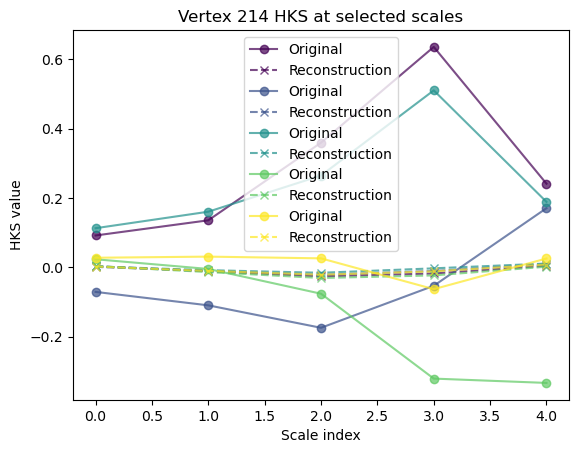

In [43]:
print(hks_np.shape) 
print(hks_recon_np.shape) 

random_indices = np.random.choice(hks_np.shape[0], size=5, replace=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(random_indices)))
for idx, i in enumerate(random_indices):
    plt.plot(hks_np[i, scale_indices], label='Original', marker='o', color=colors[idx], alpha=0.7) 
    plt.plot(hks_recon_np[i, scale_indices], label='Reconstruction', marker='x', color=colors[idx], linestyle='--', alpha=0.7)
plt.title(f'Vertex {i} HKS at selected scales')
plt.xlabel('Scale index')
plt.ylabel('HKS value')
plt.legend()
plt.show()

In [44]:
for si in scale_indices:
    print(f"\n--- HKS scale {si} (t = {ts[si]:.4f}) ---")

    print(f"Original (range: [{hks_np[:, si].min():.6f}, {hks_np[:, si].max():.6f}]):")
    plot(verts_np, faces_np, c=hks_np[:, si])

    print(f"Reconstructed (range: [{hks_recon_np[:, si].min():.6f}, {hks_recon_np[:, si].max():.6f}]):")
    plot(verts_np, faces_np, c=hks_recon_np[:, si])


--- HKS scale 0 (t = 1.0000) ---
Original (range: [-0.307218, 0.312665]):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

Reconstructed (range: [0.000812, 0.032692]):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…


--- HKS scale 5 (t = 3.3598) ---
Original (range: [-0.348661, 0.271009]):


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…


--- HKS scale 19 (t = 100.0000) ---
Original (range: [-0.397366, 0.593592]):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

Reconstructed (range: [-0.004125, 0.028455]):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

## Error map on the mesh surface

In [59]:
print("Per-vertex reconstruction error (mean over HKS scales):")
plot(verts_np, faces_np, c=per_vertex_error)
print(np.max(per_vertex_error))

Per-vertex reconstruction error (mean over HKS scales):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

0.00013132876


In [13]:
# Per-scale error maps
for si in scale_indices:
    error_si = (hks_np[:, si] - hks_recon_np[:, si])**2
    print(f"Error map — HKS scale {si} (t = {ts[si]:.4f}, MSE = {per_scale_mse[si]:.8f}):")
    plot(verts_np, faces_np, c=error_si)

Error map — HKS scale 0 (t = 1.0000, MSE = 0.00021734):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

Error map — HKS scale 5 (t = 3.3598, MSE = 0.00000618):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

Error map — HKS scale 10 (t = 11.2884, MSE = 0.00000240):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

Error map — HKS scale 15 (t = 37.9269, MSE = 0.00000648):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

Error map — HKS scale 19 (t = 100.0000, MSE = 0.00000765):


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

## Per-vertex scatter: original vs reconstructed

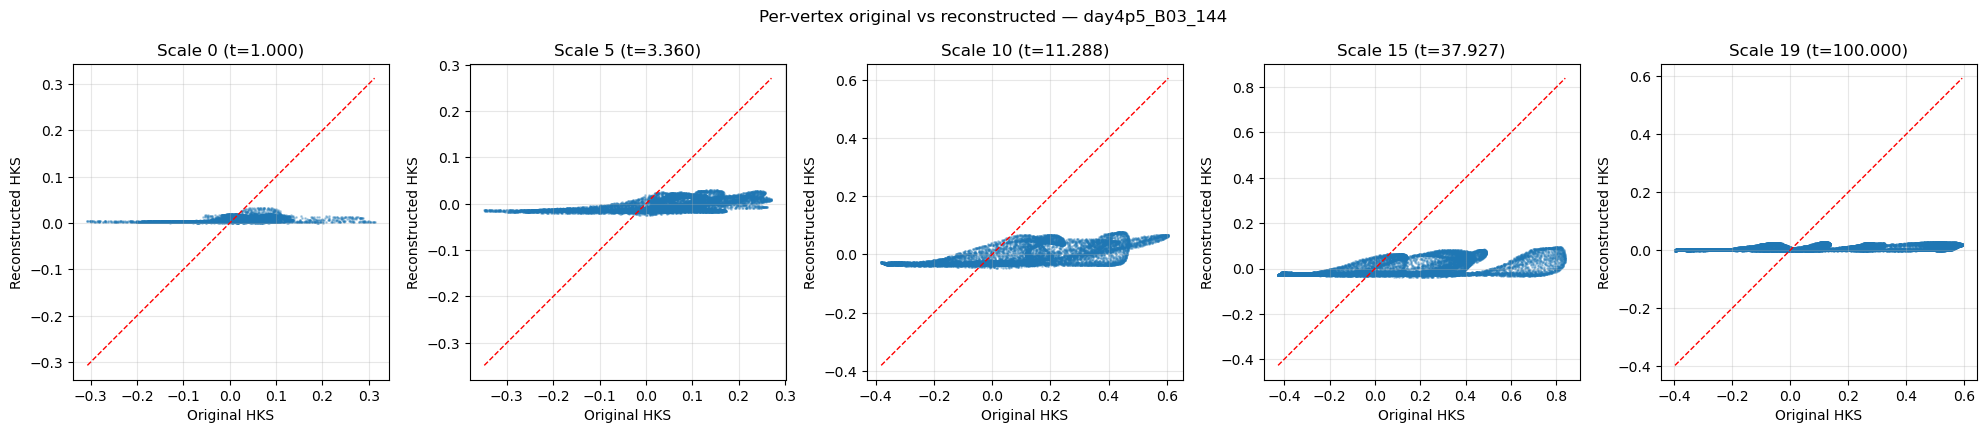

In [45]:
n_show = min(len(scale_indices), 5)
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]

for ax, si in zip(axes, scale_indices[:n_show]):
    ax.scatter(hks_np[:, si], hks_recon_np[:, si], s=1, alpha=0.3)
    lims = [min(hks_np[:, si].min(), hks_recon_np[:, si].min()),
            max(hks_np[:, si].max(), hks_recon_np[:, si].max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Original HKS')
    ax.set_ylabel('Reconstructed HKS')
    ax.set_title(f'Scale {si} (t={ts[si]:.3f})')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Per-vertex original vs reconstructed — {UID}', y=1.02)
plt.tight_layout()
plt.show()